###Business Context
**RiskShield (Revolut) – Real-Time Fraud Scoring Using Latent Transaction Patterns**

Revolut is a leading global neobank offering multi-currency accounts, instant payments, and global money movement. With millions of real-time transactions per day and high exposure to card fraud and instant payment abuse, Revolut requires a scalable fraud detection system that works even when limited features are available. This use case simulates the design of a lightweight but powerful real-time fraud scoring engine using anonymized PCA-based transaction data — similar to Revolut's production constraints in early fraud detection pipelines.

Value to Revolut:
* Deploy a lightweight, explainable fraud scoring system that functions without PII or customer metadata
* Improve fraud capture for high-velocity attacks (e.g., card testing, flash fraud) in early stages
* Minimize alert fatigue by prioritizing by Amount × Risk Score
* Provide audit-friendly justifications for blocked or investigated transactions
* Act as the “first line of defense” in Revolut’s layered fraud/AML strategy, upstream of behavioral and network models

###Dataset Overview
* 284,807 transactions from European cardholders (September 2013)
* 31 columns total
* Highly imbalanced: only 492 frauds (0.172%) out of all transactions
* 2-day transaction period
* V1-V28: PCA-transformed features (anonymized for confidentiality)
* Time: Seconds elapsed since first transaction
* Amount: Transaction amount
* Class: Target variable (1 = fraud, 0 = legitimate)

###Data Loading & Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
from sklearn.metrics import precision_recall_curve, average_precision_score
import lightgbm as lgb
import xgboost as xgb
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
import shap
import warnings
warnings.filterwarnings('ignore')

In [2]:
revolut_data = pd.read_csv('/content/drive/MyDrive/Case Studies/Revolut/datasets/creditcard.csv')

In [3]:
df = revolut_data.copy()
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.shape

(284807, 31)

Total **284,807** transactions across **31** features

In [5]:
#Summary statistics
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [6]:
#Class distribution
df['Class'].value_counts()

,count
Class,
0,284315
1,492


In [8]:
print(f"Mean Fraud Amounts: {df[df["Class"] == 1]["Amount"].mean():.2f}")
print(f"Mean Legit Amounts: {df[df["Class"] == 0]["Amount"].mean():.2f}")

Mean Fraud Amounts: 122.21
Mean Legit Amounts: 88.29


###Feature Engineering

In [9]:
#Time-based features
df['Time_hours'] = df['Time'] / 3600

#Transaction Frequency Features
df = df.sort_values('Time').reset_index(drop=True)
df['Time_diff'] = df['Time'].diff().fillna(0)

#Rolling window / Trnasaction velocity features
window_sizes = [10,50,100]
for window in window_sizes:
  df[f'amount_rolling_mean_{window}'] = df['Amount'].rolling(window=window, min_periods=1).mean()
  df[f'amount_rolling_std_{window}'] = df['Amount'].rolling(window=window, min_periods=1).std()
  df[f'time_rolling_mean_{window}'] = df['Amount'].rolling(window=window, min_periods=1).mean()

In [10]:
#Amount based risk features
df['Amount_percentile'] = df['Amount'].rank(pct=True)

#Risk-bands
amount_bins = [0,1,10,100,1000,10000,float('inf')]
amount_labels = ['micro','small','medium','large','very_large','extreme']
df['Amount_category'] = pd.cut(df['Amount'],bins=amount_bins,labels=amount_labels)

#Amount anomaly scores(distance from median in log space)
df['Amount_log'] = np.log1p(df['Amount'])
median_log_amount = df['Amount_log'].median()
df['Amount_deviation'] = np.abs(df['Amount_log'] - median_log_amount)

In [11]:
#Latent feature combinations

#Sum of absolute values of PCA components
pca_columns = [f'V{i}' for i in range(1,29)]
df['PCA_magnitude'] = np.sqrt((df[pca_columns] ** 2).sum(axis=1))

#Dominant PCA component
df['PCA_max_component'] = df[pca_columns].max(axis=1)

In [37]:
#Update feature names for modelling
feature_names = (pca_columns +
 ['Time','Amount','Time_hours','Time_diff','Amount_percentile','Amount_log','Amount_deviation','PCA_magnitude','PCA_max_component'] +
                 [col for col in df.columns if 'rolling' in col])

###Preparing Data

In [38]:
#Assign features and target
X = df[feature_names].copy()
y = df['Class'].copy()

In [39]:
#Handle any missing values from the feature engineering
X = X.fillna(X.median())

In [40]:
#Perform train-test-split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [41]:
#Scale features(robust to oyrliers- important for fintechs)
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training Fraud Rate: {y_train.mean():.3%}")
print(f"Test Fraud Rate: {y_test.mean():.3%}")

Training Fraud Rate: 0.173%
Test Fraud Rate: 0.172%


###Anomaly Detection

In [18]:
#Train on legitimate transactions only (unsupervised approach)
legit_train = X_train_scaled[y_train == 0]

In [20]:
#Building isolation forest
iso_forest = IsolationForest(
    contamination = 0.002,  # Expected Fraud Rate
    random_state = 2,
    n_jobs =-1
)

iso_forest.fit(legit_train)

IsolationForest(contamination=0.002, n_jobs=-1, random_state=2)

In [23]:
#Predict anomaly scores
train_anomaly_scores = iso_forest.decision_function(X_train_scaled)
test_anomaly_scores = iso_forest.decision_function(X_test_scaled)

In [24]:
#Add anomaly scores as features'
X_train['anomaly_score'] = train_anomaly_scores
X_test['anomaly_score'] = test_anomaly_scores

feature_names.append('anomaly_score')

In [25]:
#Evaluate anomaly detection performance
test_anomaly_preds = iso_forest.predict(X_test_scaled)
test_anomaly_preds = (test_anomaly_preds == -1).astype(int)

anomaly_precision = (y_test[test_anomaly_preds == 1] == 1).mean()
anomaly_recall = (test_anomaly_preds[y_test == 1] ==1).mean()

print(f"Anomaly Precision: {anomaly_precision: .3f}")
print(f"Anomaly Recall: {anomaly_recall: .3f}")

Anomaly Precision:  0.115
Anomaly Recall:  0.153


In [26]:
models = {}

models['isolation_forest'] = iso_forest
iso_forest

IsolationForest(contamination=0.002, n_jobs=-1, random_state=2)

###Train Classification Models

In [42]:
#Handle class imbalance with SMOTE + RandomUnderSampler
over = SMOTE(sampling_strategy=0.1,random_state=42) #Increase fraud to 10% of majority
under = RandomUnderSampler(sampling_strategy=0.2,random_state=42) #final ratio 1:5

X_resampled,y_resampled = over.fit_resample(X_train_scaled,y_train)
X_resampled,y_resampled = under.fit_resample(X_resampled,y_resampled)

In [43]:
#Logistic Regression (iterpretable baseline)
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight='balanced'
)

lr_model.fit(X_resampled,y_resampled)
models['logistic_regression'] = lr_model

In [44]:
#LightGBM (faster gradient boosting)
lgb_model = lgb.LGBMClassifier(
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    num_leaves=31,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    class_weight='balanced',
    verbose=-1
)

lgb_model.fit(X_resampled,y_resampled)
models['lightgbm'] = lgb_model

In [45]:
#XGboost (robust gradient boosting)
scale_pos_weight= (y_resampled == 0).sum() / (y_resampled==1).sum()

xgb_model = xgb.XGBClassifier(
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss'
)

xgb_model.fit(X_resampled,y_resampled)
models['xgboost'] = xgb_model

###Evaluate models

In [32]:
from sklearn.metrics import precision_recall_curve, average_precision_score

In [47]:
#Evaluating model performances with fintech-relevant metrics
results={}

for model_name, model in models.items():
  if model_name == 'isolation_forest':
    continue

  y_pred_proba = model.predict_proba(X_test)[:,1]
  y_pred = (y_pred_proba >= 0.5).astype(int)

  auc_score = roc_auc_score(y_test,y_pred_proba)
  precision,recall,_ = precision_recall_curve(y_test,y_pred_proba)
  # Sort precision and recall values to ensure correct order for AUC calculation
  sorted_indices = np.argsort(recall)
  precision = precision[sorted_indices]
  recall = recall[sorted_indices]
  pr_auc = auc(recall,precision)
  avg_precision = average_precision_score(y_test,y_pred_proba)

  report = classification_report(y_test,y_pred,output_dict=True)

  results[model_name] = {
      'auc_roc': auc_score,
      'auc_pr': pr_auc,
      'avg_precision': avg_precision,
      'precision_fraud': report['1']['precision'],
      'recall_fraud': report['1']['recall'],
      'f1_fraud': report['1']['f1-score'],
      'precision_legit': report['0']['precision'],
      'recall_legit': report['0']['recall'],
      'predictions': y_pred
  }

  print(f"AUC-ROC: {auc_score:.4f}")
  print(f"PR-AUC: {pr_auc:.4f}")
  print(f"Avg Precision: {avg_precision:.4f}")
  print(f"Fraud Precision: {report['1']['precision']:.4f}")
  print(f"Fraud Recall: {report['1']['recall']:.4f}")
  print(f"Fraud F1: {report['1']['f1-score']:.4f}")

AUC-ROC: 0.5070
PR-AUC: 0.0058
Avg Precision: 0.0020
Fraud Precision: 0.0000
Fraud Recall: 0.0000
Fraud F1: 0.0000
AUC-ROC: 0.9739
PR-AUC: 0.7202
Avg Precision: 0.7195
Fraud Precision: 0.4725
Fraud Recall: 0.8776
Fraud F1: 0.6143
AUC-ROC: 0.9689
PR-AUC: 0.7500
Avg Precision: 0.7491
Fraud Precision: 0.3452
Fraud Recall: 0.8878
Fraud F1: 0.4971


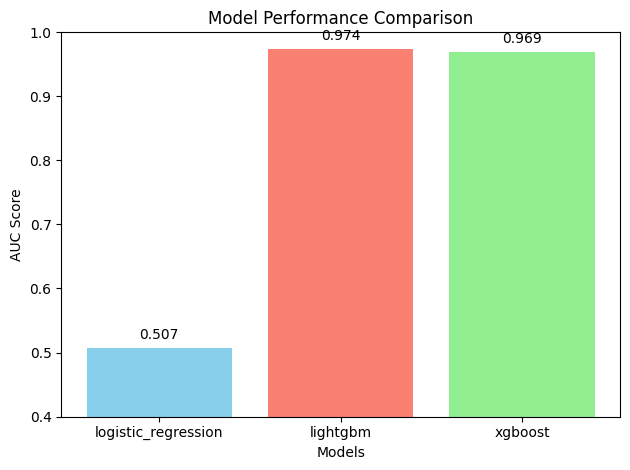

In [52]:
#Comparing model performances based on AUC Score
model_names = list(results.keys())
auc_scores = [results[name]['auc_roc'] for name in model_names]

colors = ['skyblue','salmon','lightgreen']
bars = plt.bar(model_names,auc_scores,color=colors[:len(model_names)])
plt.xlabel('Models')
plt.ylabel('AUC Score')
plt.title('Model Performance Comparison')
plt.ylim(0.4,1.0)
for bar, score in zip(bars, auc_scores):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                          f'{score:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

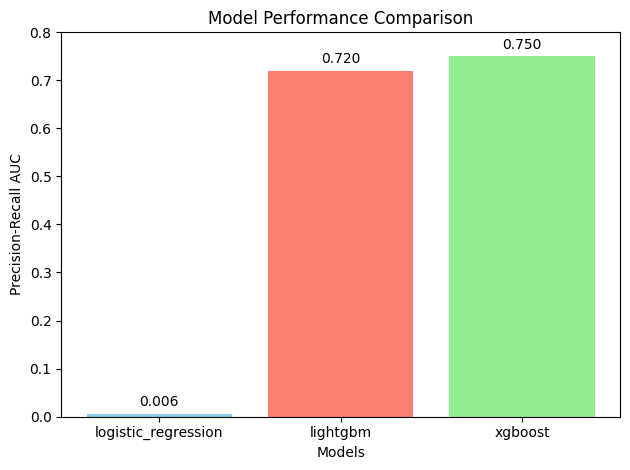

In [51]:
#Comparing model performances based on PR-AUC
model_names = list(results.keys())
pr_aucs = [results[name]['auc_pr'] for name in model_names]

colors = ['skyblue','salmon','lightgreen']
bars = plt.bar(model_names,pr_aucs,color=colors[:len(model_names)])
plt.xlabel('Models')
plt.ylabel('Precision-Recall AUC')
plt.title('Model Performance Comparison')
plt.ylim(0.0,0.8)
for bar, score in zip(bars, pr_aucs):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                          f'{score:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [53]:
#Best model based on AUC-ROC
best_model_name= max(results.keys(),key=lambda x: results[x]['auc_roc'])
print(f"Best Model: {best_model_name.upper()} AUC-ROC: {results[best_model_name]['auc_roc']:.4f}")

Best Model: LIGHTGBM AUC-ROC: 0.9739


In [54]:
#Best model based on Precision-Recall AUC
best_model_name= max(results.keys(),key=lambda x: results[x]['auc_pr'])
print(f"Best Model: {best_model_name.upper()} AUC-PR: {results[best_model_name]['auc_pr']:.4f}")

Best Model: XGBOOST AUC-PR: 0.7500


In [55]:
evaluation_results = results
best_model_name = best_model_name

####Why consider PR-AUC instead of normal AUC score?
**What exactly is Precision-Recall AUC?** *focuses specifically on the performance of the model on the positive class(fraud) and highlights the trade-off between precision and recall*

**Why choose PR-AUC?** *much more realistic picture of a model's performance in catching fraud while minimizing false alarms*

Most fraud datasets are **highly imbalanced**.

Thus, evaluating the model's performance based on only a **single metric**(i.e. AUC score) can be misleading - why? because, *it evaluates a model's ability to ditinguish between positive and negative classes across all classification thresholds*.

A good model for fraud detection will have both **high precision**(minimizes false alarms;improves operational efficiency) and **high recall**(maximizes fraud caught;minimizes financial losses).

In the context of Fraud Detection,
cost of **FN(fraud transaction missed)** > cost of **FP(legit transaction flagged as fraud)**



###Optimize Threshold

In [57]:
#Cost based threshold optimization for business impact
best_model = models[best_model_name]
y_pred_proba =  best_model.predict_proba(X_test_scaled)[:,1]

thresholds = np.arange(0.01,1.0,0.01)
cost_fp = 1
cost_fn = 10
costs=[]
metrics= []

for threshold in thresholds:
  y_pred = (y_pred_proba >= threshold).astype(int)

  tn,fp,fn,tp = confusion_matrix(y_test,y_pred).ravel()

  total_cost = (fp*cost_fp) + (fn*cost_fn)
  costs.append(total_cost)

  precision = tp/(tp+fp) if (tp+fp)>0 else 0
  recall = tp/(tp+fn) if (tp+fn) else 0
  f1 = 2 * (precision*recall) / (precision + recall) if (precision+recall) >0 else 0

  metrics.append({
      'threshold': threshold,
      'cost': total_cost,
      'precision': precision,
      'recall': recall,
      'f1': f1,
      'tp':tp,'fp':fp,'tn':tn, 'fn':fn
      })

optimal_idx = np.argmin(costs)
optimal_threshold = thresholds[optimal_idx]
optimal_metrics = metrics[optimal_idx]

print(f"Optimal threshold: {optimal_threshold:.3f}")
print(f"• Minimum cost: ${optimal_metrics['cost']:.0f}")
print(f"• Precision: {optimal_metrics['precision']:.3f}")
print(f"• Recall: {optimal_metrics['recall']:.3f}")
print(f"• F1-Score: {optimal_metrics['f1']:.3f}")
print(f"• True Positives: {optimal_metrics['tp']}")
print(f"• False Positives: {optimal_metrics['fp']}")
print(f"• False Negatives: {optimal_metrics['fn']}")

Optimal threshold: 0.700
• Minimum cost: $162
• Precision: 0.626
• Recall: 0.888
• F1-Score: 0.734
• True Positives: 87
• False Positives: 52
• False Negatives: 11


In [58]:
risk_thresholds = {}

risk_thresholds['optimal'] = optimal_threshold
risk_thresholds['conservative'] = optimal_threshold * 0.7  # Lower threshold for higher recall
risk_thresholds['aggressive'] = optimal_threshold * 1.3   # Higher threshold for higher precision

In [59]:
optimal_metrics

{'threshold': np.float64(0.7000000000000001),
 'cost': np.int64(162),
 'precision': np.float64(0.6258992805755396),
 'recall': np.float64(0.8877551020408163),
 'f1': np.float64(0.7341772151898734),
 'tp': np.int64(87),
 'fp': np.int64(52),
 'tn': np.int64(56812),
 'fn': np.int64(11)}

###SHAP Model Explainations

In [63]:
#Shap explainability for audit and compliance
best_model = models[best_model_name]

sample_size = 1000
sample_indices = np.random.choice(len(X_test_scaled),
                                        min(sample_size, len(X_test_scaled)),
                                        replace=False)

X_sample = X_test_scaled[sample_indices]

In [66]:
# Create SHAP explainer
if best_model_name in ['lightgbm', 'xgboost']:
  explainer = shap.TreeExplainer(best_model)
else:
  explainer = shap.LinearExplainer(best_model, X_train_scaled)

In [67]:
# Calculate SHAP values
shap_values = explainer.shap_values(X_sample)

# For binary classification, get positive class SHAP values
if len(shap_values) == 2:
  shap_values = shap_values[1]

In [68]:
# Feature importance summary
feature_importance = np.abs(shap_values).mean(axis=0)
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

for i, row in feature_importance_df.head(10).iterrows():
  print(f"• {row['feature']}: {row['importance']:.4f}")

shap_values = shap_values
shap_explainer = explainer
feature_importance = feature_importance_df

• V14: 1.4311
• V4: 1.2474
• PCA_magnitude: 0.7597
• V12: 0.4299
• V10: 0.3652
• V1: 0.3609
• V3: 0.3316
• V8: 0.3180
• Time_diff: 0.3150
• V18: 0.2147


In [69]:
feature_importance_df

,feature,importance
13,V14,1.431116
3,V4,1.247364
35,PCA_magnitude,0.759704
11,V12,0.429938
9,V10,0.365245
0,V1,0.360861
2,V3,0.331631
7,V8,0.317982
31,Time_diff,0.314973
17,V18,0.214739


###Real-time scoring simulation

In [85]:
#Simulate real-time transaction scoring

# Select random transactions from test set
n_transactions = 10000
sample_indices = np.random.choice(len(X_test_scaled), n_transactions, replace=False)
X_sample = X_test_scaled[sample_indices]
y_sample = y_test.iloc[sample_indices]

best_model = models[best_model_name]

In [86]:
# Real-time predictions
risk_scores = best_model.predict_proba(X_sample)[:, 1]

In [87]:
# Apply thresholds
decisions = pd.DataFrame({
    'transaction_id': range(len(sample_indices)),
    'actual_fraud': y_sample.values,
    'risk_score': risk_scores,
    'conservative_flag': risk_scores >= risk_thresholds['conservative'],
    'optimal_flag': risk_scores >= risk_thresholds['optimal'],
    'aggressive_flag': risk_scores >= risk_thresholds['aggressive'],
    'amount': df.iloc[sample_indices]['Amount'].values
})

In [88]:
# Priority scoring (Amount × Risk Score)
decisions['priority_score'] = decisions['amount'] * decisions['risk_score']
decisions = decisions.sort_values('priority_score', ascending=False)

In [89]:
# Summary statistics
print(f"• High-risk transactions (conservative): {decisions['conservative_flag'].sum()}")
print(f"• High-risk transactions (optimal): {decisions['optimal_flag'].sum()}")
print(f"• High-risk transactions (aggressive): {decisions['aggressive_flag'].sum()}")
print(f"• Actual frauds in sample: {decisions['actual_fraud'].sum()}")

• High-risk transactions (conservative): 39
• High-risk transactions (optimal): 28
• High-risk transactions (aggressive): 22
• Actual frauds in sample: 20


In [90]:
# Alert prioritization
alerts = decisions[decisions['optimal_flag'] == True].copy()
if len(alerts) > 0:
  print(f"• Average risk score of alerts: {alerts['risk_score'].mean():.3f}")
  print(f"• Average amount of alerts: ${alerts['amount'].mean():.2f}")
  print(f"• Top priority alert amount: ${alerts['amount'].iloc[0]:.2f}")

simulation_results = decisions

• Average risk score of alerts: 0.960
• Average amount of alerts: $579.94
• Top priority alert amount: $12910.93


###Executive Dashboard Summary

In [92]:
# Model performance
best_results = evaluation_results[best_model_name]
print(f"Model Performance ({best_model_name.upper()}):")
print(f"• AUC-ROC Score: {best_results['auc_roc']:.4f}")
print(f"• AUC-PR Score: {best_results['auc_pr']:.4f}")
print(f"• Fraud Detection Rate: {best_results['recall_fraud']:.1%}")
print(f"• False Positive Rate: {1-best_results['precision_fraud']:.1%}")

Model Performance (XGBOOST):
• AUC-ROC Score: 0.9689
• AUC-PR Score: 0.7500
• Fraud Detection Rate: 88.8%
• False Positive Rate: 65.5%


In [94]:
# Business impact
if 'simulation_results' in locals():
  sim = simulation_results
  fraud_caught = sim[(sim['actual_fraud']==1) & (sim['optimal_flag']==True)]
  total_frauds = sim[sim['actual_fraud']==1]

  if len(total_frauds) > 0:
    catch_rate = len(fraud_caught) / len(total_frauds)
    print(f"\nBusiness Impact:")
    print(f"• Fraud Catch Rate: {catch_rate:.1%}")
    print(f"• Alert Volume: {sim['optimal_flag'].mean():.1%} of transactions")

    if len(fraud_caught) > 0:
      prevented_loss = fraud_caught['amount'].sum()
      print(f"• Prevented Loss (sample): ${prevented_loss:.2f}")


Business Impact:
• Fraud Catch Rate: 95.0%
• Alert Volume: 0.3% of transactions
• Prevented Loss (sample): $14306.63


In [97]:
# Top risk factors
if 'feature_importance' in locals():
  print(f"\n Top Risk Indicators:")
  for i, row in feature_importance.head(5).iterrows():
    print(f"• {row['feature']}: {row['importance']:.4f}")


 Top Risk Indicators:
• V14: 1.4311
• V4: 1.2474
• PCA_magnitude: 0.7597
• V12: 0.4299
• V10: 0.3652


In [99]:
# Operational metrics
print(f"\n Operational Metrics:")
print(f"• Training Data: {len(X_train_scaled):,} transactions")
print(f"• Model Features: {len(feature_names)} features")
print(f"• Optimal Threshold: {risk_thresholds['optimal']:.3f}")
print(f"• Conservative Threshold: {risk_thresholds['conservative']:.3f}")


 Operational Metrics:
• Training Data: 227,845 transactions
• Model Features: 46 features
• Optimal Threshold: 0.700
• Conservative Threshold: 0.490


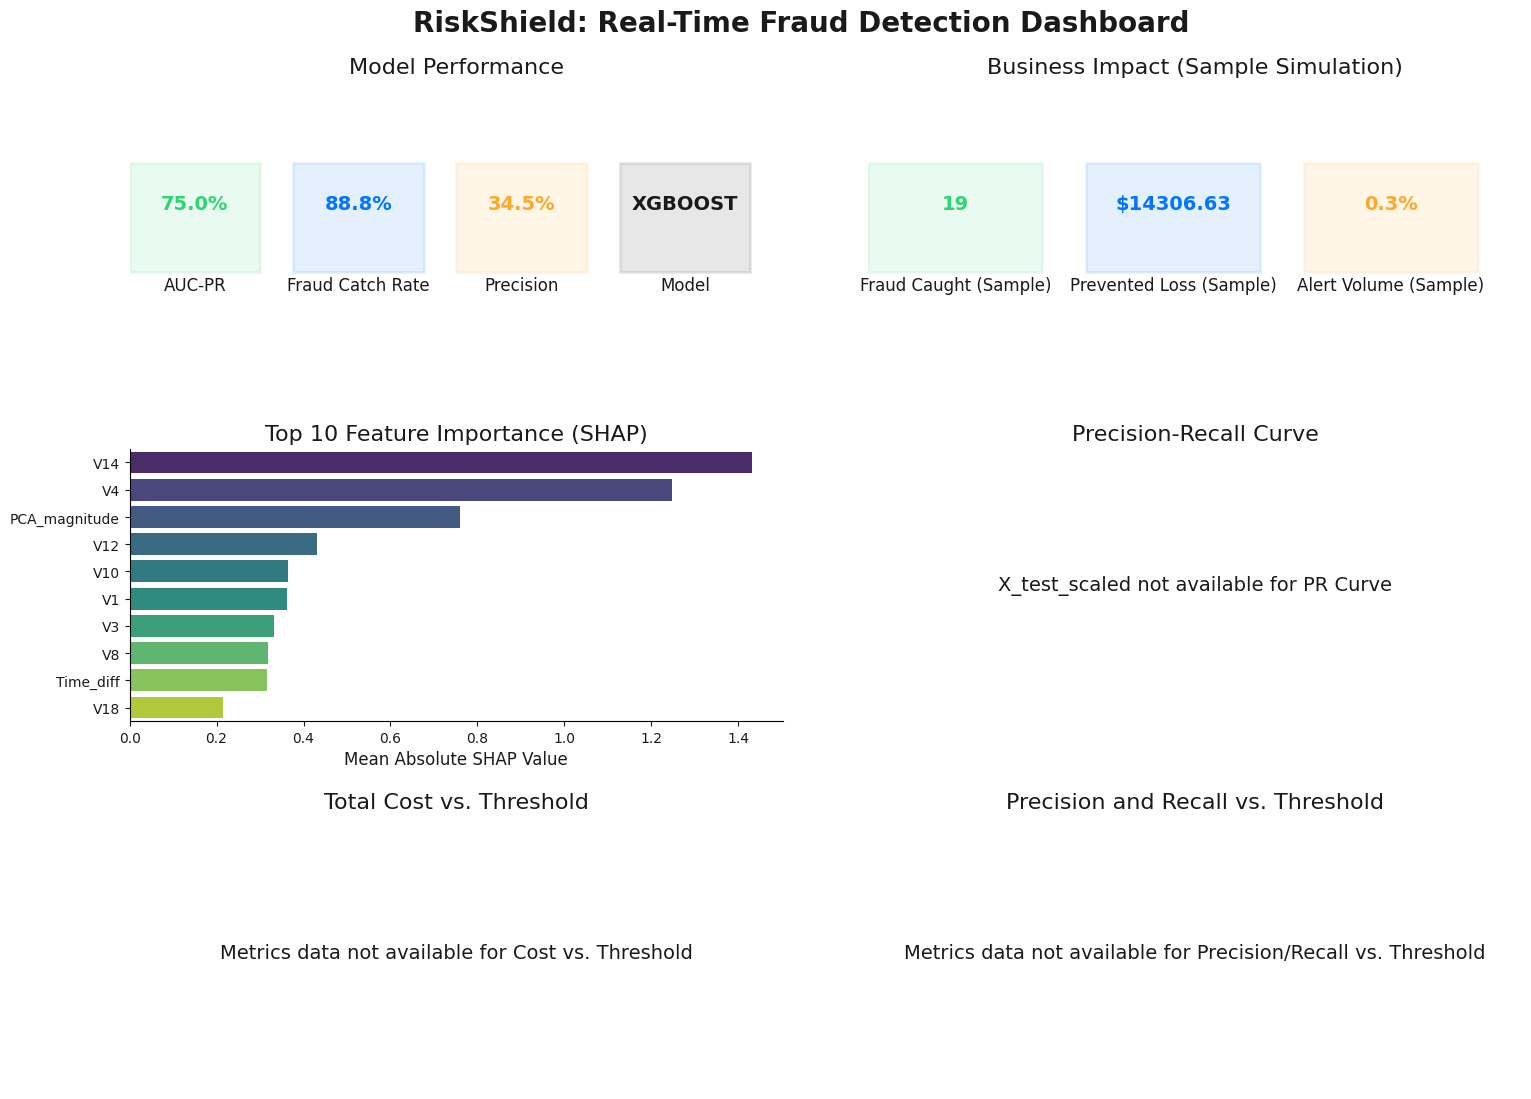

In [100]:
from matplotlib.patches import Rectangle

plt.style.use('default')
sns.set_palette("husl")

def create_dashboard(evaluation_results, best_model_name, simulation_results, feature_importance, figsize=(16, 12)):
    # Revolut brand colors (approximation)
    REVOLUT_BLUE = '#0075FF'
    REVOLUT_DARK = '#1A1A1A'
    FRAUD_RED = '#FF4757'
    SUCCESS_GREEN = '#2ED573'
    WARNING_ORANGE = '#FFA726'

    fig = plt.figure(figsize=figsize, facecolor='white')
    fig.suptitle('RiskShield: Real-Time Fraud Detection Dashboard',
                 fontsize=20, fontweight='bold', color=REVOLUT_DARK, y=0.98)

    # Create grid layout
    gs = fig.add_gridspec(3, 4, hspace=0.35, wspace=0.3,
                         left=0.08, right=0.95, top=0.92, bottom=0.08)

    # =================== ROW 1: KEY METRICS ===================

    # 1. Model Performance KPIs
    ax1 = fig.add_subplot(gs[0, 0:2])

    best_results = evaluation_results[best_model_name]

    # KPI boxes
    kpis = [
        ('AUC-PR', best_results['auc_pr'], SUCCESS_GREEN), # Using auc_pr from results
        ('Fraud Catch Rate', best_results['recall_fraud'], REVOLUT_BLUE),
        ('Precision', best_results['precision_fraud'], WARNING_ORANGE),
        ('Model', best_model_name.upper(), REVOLUT_DARK)
    ]

    ax1.set_xlim(0, 4)
    ax1.set_ylim(0, 1)

    for i, (label, value, color) in enumerate(kpis):
        if isinstance(value, float):
            display_value = f'{value:.1%}' if value <= 1 else f'{value:.3f}'
        else:
            display_value = str(value)

        # KPI box
        rect = Rectangle((i, 0.3), 0.8, 0.4, facecolor=color, alpha=0.1, edgecolor=color, linewidth=2)
        ax1.add_patch(rect)

        # Value
        ax1.text(i+0.4, 0.55, display_value, ha='center', va='center',
                fontsize=14, fontweight='bold', color=color)
        # Label
        ax1.text(i+0.4, 0.25, label, ha='center', va='center',
                fontsize=12, color=REVOLUT_DARK)

    ax1.axis('off')
    ax1.set_title('Model Performance', fontsize=16, color=REVOLUT_DARK)


    # 2. Business Impact KPIs
    ax2 = fig.add_subplot(gs[0, 2:4])

    if 'simulation_results' in locals():
      sim = simulation_results
      fraud_caught = sim[(sim['actual_fraud']==1) & (sim['optimal_flag']==True)]
      total_frauds = sim[sim['actual_fraud']==1]

      if len(total_frauds) > 0:
        catch_rate = len(fraud_caught) / len(total_frauds)
        prevented_loss = fraud_caught['amount'].sum() if len(fraud_caught) > 0 else 0

        business_kpis = [
            ('Fraud Caught (Sample)', len(fraud_caught), SUCCESS_GREEN),
            ('Prevented Loss (Sample)', f'${prevented_loss:.2f}', REVOLUT_BLUE),
            ('Alert Volume (Sample)', sim['optimal_flag'].mean(), WARNING_ORANGE)
        ]

        ax2.set_xlim(0, 3)
        ax2.set_ylim(0, 1)

        for i, (label, value, color) in enumerate(business_kpis):
            if isinstance(value, float):
                 display_value = f'{value:.1%}' if value <= 1 else f'{value:.0f}'
            else:
                display_value = str(value)

            rect = Rectangle((i, 0.3), 0.8, 0.4, facecolor=color, alpha=0.1, edgecolor=color, linewidth=2)
            ax2.add_patch(rect)

            ax2.text(i+0.4, 0.55, display_value, ha='center', va='center',
                    fontsize=14, fontweight='bold', color=color)
            ax2.text(i+0.4, 0.25, label, ha='center', va='center',
                    fontsize=12, color=REVOLUT_DARK)

        ax2.axis('off')
        ax2.set_title('Business Impact (Sample Simulation)', fontsize=16, color=REVOLUT_DARK)
      else:
        ax2.text(0.5, 0.5, "No frauds in sample", ha='center', va='center', fontsize=14, color=REVOLUT_DARK)
        ax2.axis('off')
        ax2.set_title('Business Impact (Sample Simulation)', fontsize=16, color=REVOLUT_DARK)


    # =================== ROW 2: VISUALIZATIONS ===================

    # 3. Feature Importance Plot
    ax3 = fig.add_subplot(gs[1, 0:2])
    if 'feature_importance' in locals():
      top_features = feature_importance.head(10)
      sns.barplot(x='importance', y='feature', data=top_features, ax=ax3, palette='viridis')
      ax3.set_title('Top 10 Feature Importance (SHAP)', fontsize=16, color=REVOLUT_DARK)
      ax3.set_xlabel('Mean Absolute SHAP Value', fontsize=12, color=REVOLUT_DARK)
      ax3.set_ylabel('')
      ax3.tick_params(axis='both', colors=REVOLUT_DARK)
      ax3.spines['top'].set_visible(False)
      ax3.spines['right'].set_visible(False)


    # 4. Precision-Recall Curve
    ax4 = fig.add_subplot(gs[1, 2:4])
    if best_model_name in evaluation_results:
        best_model = models[best_model_name]
        # Need X_test_scaled for prediction, assuming it's available
        if 'X_test_scaled' in locals():
            y_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]
            precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
            pr_auc = auc(recall, precision)

            ax4.plot(recall, precision, color=REVOLUT_BLUE, lw=2, label=f'{best_model_name.upper()} (AUC = {pr_auc:.2f})')
            ax4.set_xlabel('Recall', fontsize=12, color=REVOLUT_DARK)
            ax4.set_ylabel('Precision', fontsize=12, color=REVOLUT_DARK)
            ax4.set_title('Precision-Recall Curve', fontsize=16, color=REVOLUT_DARK)
            ax4.legend(loc='lower left')
            ax4.set_ylim([0.0, 1.05])
            ax4.set_xlim([0.0, 1.0])
            ax4.grid(True, linestyle='--', alpha=0.6)
            ax4.tick_params(axis='both', colors=REVOLUT_DARK)
            ax4.spines['top'].set_visible(False)
            ax4.spines['right'].set_visible(False)
        else:
             ax4.text(0.5, 0.5, "X_test_scaled not available for PR Curve", ha='center', va='center', fontsize=14, color=REVOLUT_DARK)
             ax4.axis('off')
             ax4.set_title('Precision-Recall Curve', fontsize=16, color=REVOLUT_DARK)


    # =================== ROW 3: THRESHOLD ANALYSIS ===================

    # 5. Cost vs. Threshold
    ax5 = fig.add_subplot(gs[2, 0:2])
    if 'metrics' in locals():
      costs = [m['cost'] for m in metrics]
      thresholds = [m['threshold'] for m in metrics]
      ax5.plot(thresholds, costs, color=REVOLUT_BLUE, lw=2)
      ax5.axvline(x=optimal_threshold, color=FRAUD_RED, linestyle='--', label=f'Optimal Threshold ({optimal_threshold:.2f})')
      ax5.set_xlabel('Threshold', fontsize=12, color=REVOLUT_DARK)
      ax5.set_ylabel('Total Cost ($)', fontsize=12, color=REVOLUT_DARK)
      ax5.set_title('Total Cost vs. Threshold', fontsize=16, color=REVOLUT_DARK)
      ax5.legend()
      ax5.grid(True, linestyle='--', alpha=0.6)
      ax5.tick_params(axis='both', colors=REVOLUT_DARK)
      ax5.spines['top'].set_visible(False)
      ax5.spines['right'].set_visible(False)
    else:
      ax5.text(0.5, 0.5, "Metrics data not available for Cost vs. Threshold", ha='center', va='center', fontsize=14, color=REVOLUT_DARK)
      ax5.axis('off')
      ax5.set_title('Total Cost vs. Threshold', fontsize=16, color=REVOLUT_DARK)


    # 6. Precision/Recall vs. Threshold
    ax6 = fig.add_subplot(gs[2, 2:4])
    if 'metrics' in locals():
      precision_vals = [m['precision'] for m in metrics]
      recall_vals = [m['recall'] for m in metrics]
      thresholds = [m['threshold'] for m in metrics]

      ax6.plot(thresholds, precision_vals, color=SUCCESS_GREEN, lw=2, label='Precision')
      ax6.plot(thresholds, recall_vals, color=FRAUD_RED, lw=2, label='Recall')
      ax6.axvline(x=optimal_threshold, color=REVOLUT_BLUE, linestyle='--', label=f'Optimal Threshold ({optimal_threshold:.2f})')

      ax6.set_xlabel('Threshold', fontsize=12, color=REVOLUT_DARK)
      ax6.set_ylabel('Score', fontsize=12, color=REVOLUT_DARK)
      ax6.set_title('Precision and Recall vs. Threshold', fontsize=16, color=REVOLUT_DARK)
      ax6.legend()
      ax6.set_ylim([0.0, 1.05])
      ax6.grid(True, linestyle='--', alpha=0.6)
      ax6.tick_params(axis='both', colors=REVOLUT_DARK)
      ax6.spines['top'].set_visible(False)
      ax6.spines['right'].set_visible(False)
    else:
      ax6.text(0.5, 0.5, "Metrics data not available for Precision/Recall vs. Threshold", ha='center', va='center', fontsize=14, color=REVOLUT_DARK)
      ax6.axis('off')
      ax6.set_title('Precision and Recall vs. Threshold', fontsize=16, color=REVOLUT_DARK)


    plt.show()

# Display the dashboard
create_dashboard(evaluation_results, best_model_name, simulation_results, feature_importance)